# Graded Response Model — PROMIS Substance Use (Single Scale)

Fits a single-dimensional GRM to the PROMIS Substance Use item bank.
Data from Harvard Dataverse (doi:10.7910/DVN/VLCJUE).

Item columns are auto-detected on first load. Verify that the
detected items match the expected PROMIS SUDS banks (Severity: 37 items,
Positive Appeal: 18 items).

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data

In [2]:
from bayesianquilts.data.promis_substance_use import get_data, item_keys, response_cardinality

df, num_people = get_data(reorient=True, polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {response_cardinality} response categories (0-{response_cardinality - 1})")
print(f"Item keys: {item_keys[:10]}... ({len(item_keys)} total)")
df.head()

Detected 144 substance use items (sd*R* pattern)


Dataset: 1793 people, 144 items, 5 response categories (0-4)
Item keys: ['sd1083R1d', 'sd11004R1', 'sd11007R1', 'sd11015R1', 'sd11022R1d', 'sd11024R1d', 'sd11138R1d', 'sd11165R1d', 'sd1116R1d', 'sd11193R1d']... (144 total)


person,sd1083R1d,sd11004R1,sd11007R1,sd11015R1,sd11022R1d,sd11024R1d,sd11138R1d,sd11165R1d,sd1116R1d,sd11193R1d,sd11200R1d,sd11208R1d,sd11229R1d,sd11252R1d,sd11299R1d,sd11316R1d,sd11323R1d,sd11350R1d,sd11356R1d,sd11487R1d,sd11508R1d,sd11548R1d,sd11549R1d,sd11571R3d,sd11594R1d,sd11598R2d,sd11624R1d,sd11628R1d,sd11633R1d,sd11635R1d,sd11672R1d,sd11713R1d,sd11751R1d,sd11764R1d,sd11777R1,sd11777R2,…,sd1594R1d,sd1760R1d,sd1817R1d,sd1836R1d,sd1876R1d,sd2142R1d,sd229R1d,sd2360R2d,sd2823R1,sd2828R1d,sd2842R1d,sd2843R1d,sd2888R1d,sd2894R2d,sd2908R1d,sd3289R2d,sd3291R1d,sd3604R1d,sd3738R1,sd3750R1,sd3752R1,sd3761R2,sd3765R1,sd3938R1d,sd3942R1d,sd3984R1,sd4182R1,sd4619R1d,sd500R1,sd5069R1,sd512R1,sd5272R1d,sd68R1d,sd789R2d,sd792R1d,sd795R2d,sd970R1d
u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,…,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,-1.0,2.0,2.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,3.0,3.0,…,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,3.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,4.0,0.0,0.0,0.0,4.0,-1.0,-1.0,4.0,4.0,-1.0,3.0,3.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,…,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,2.0,-1.0,-1.0,-1.0,1.0,2.0,4.0,2.0,4.0,4.0,2.0,4.0,4.0,2.0,4.0,4.0,4.0,0.0,0.0,1.0,2.0,4.0,4.0,4.0,2.0,4.0,2.0,2.0,2.0,4.0,2.0,4.0,4.0,4.0,-1.0,-1.0,…,2.0,0.0,2.0,2.0,2.0,0.0,2.0,0.0,-1.0,2.0,0.0,0.0,4.0,4.0,2.0,2.0,4.0,4.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0,2.0,-1.0,-1.0,2.0,-1.0,-1.0,-1.0,3.0,1.0,0.0,1.0,2.0,2.0
4,3.0,-1.0,-1.0,-1.0,2.0,2.0,3.0,2.0,4.0,3.0,1.0,4.0,2.0,3.0,4.0,3.0,4.0,3.0,3.0,0.0,1.0,3.0,3.0,4.0,2.0,1.0,3.0,3.0,4.0,4.0,3.0,2.0,2.0,2.0,-1.0,-1.0,…,3.0,0.0,4.0,3.0,3.0,2.0,1.0,2.0,-1.0,0.0,1.0,0.0,4.0,3.0,1.0,4.0,4.0,4.0,-1.0,-1.0,-1.0,-1.0,-1.0,3.0,1.0,-1.0,-1.0,4.0,-1.0,-1.0,-1.0,2.0,2.0,2.0,2.0,2.0,1.0


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 1793


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 146066
N: 1793, Batch size: 256, Steps per epoch: 8


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Final baseline loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/8 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/8 [00:03<?, ?batch/s, best_loss=inf, loss=137.2287]

Epoch 1/200 (LR: 0.000200):  12%|█▎        | 1/8 [00:03<00:27,  3.97s/batch, best_loss=inf, loss=137.2287]

Epoch 1/200 (LR: 0.000200):  12%|█▎        | 1/8 [00:04<00:27,  3.97s/batch, best_loss=inf, loss=142.4945]

...

Epoch 21/200 (LR: 0.000140):  62%|██████▎   | 5/8 [00:04<00:01,  2.00batch/s, best_loss=117.8874, loss=135.5917]

Epoch 21/200 (LR: 0.000140):  62%|██████▎   | 5/8 [00:04<00:01,  2.00batch/s, best_loss=117.8874, loss=125.8690]

Epoch 21/200 (LR: 0.000140):  62%|██████▎   | 5/8 [00:06<00:01,  2.00batch/s, best_loss=117.8874, loss=6.4870]  

Epoch 21/200 (LR: 0.000140): 100%|██████████| 8/8 [00:06<00:00,  1.60batch/s, best_loss=117.8874, loss=6.4870]

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000137

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
Final baseline loss: 119.37


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit Pairwise Ordinal Stacking Model

In [8]:
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

# Convert to pandas, replacing -1 (missing marker) with NaN
pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)
print(f"Missing values per item:\n{pandas_df.isna().sum()}")

pairwise_model = PairwiseOrdinalStackingModel(
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

pairwise_model.fit(
    pandas_df,
    n_top_features=12,
    n_jobs=-1,
    seed=42,
)

Missing values per item:
sd1083R1d      944
sd11004R1     1332
sd11007R1     1333
sd11015R1     1335
sd11022R1d     950
              ... 
sd68R1d        948
sd789R2d       949
sd792R1d       948
sd795R2d       950
sd970R1d       949
Length: 144, dtype: int64
Computing feature correlations...


Fitting PairwiseOrdinalStackingModel
  Variables: 144
  Observations: 1793
  Min obs per model: 5
  Parallel jobs: -1
  Top features per target: 12
  DM alpha prior: 0.5
  Global ordinal values: [0. 1. 2. 3. 4.] (n=5)

Fitting marginal regression models...
  144 of 144 remaining


  Var 0 (sd1083R1d): elpd/n=-0.7460
  Var 1 (sd11004R1): elpd/n=-1.1831
  Var 2 (sd11007R1): elpd/n=-1.2957
  Var 3 (sd11015R1): elpd/n=-1.2403
  Var 4 (sd11022R1d): elpd/n=-0.8391


  Var 5 (sd11024R1d): elpd/n=-0.6574
  Var 6 (sd11138R1d): elpd/n=-0.7090
  Var 7 (sd11165R1d): elpd/n=-0.7142


  Var 8 (sd1116R1d): elpd/n=-0.8543
  Var 9 (sd11193R1d): elpd/n=-0.7507
  Var 10 (sd11200R1d): elpd/n=-0.6130
  Var 11 (sd11208R1d): elpd/n=-0.6923
  Var 12 (sd11229R1d): elpd/n=-0.6664


...

  DM (sd11193R1d->sd795R2d): elpd/n=-0.8806, n=842
  DM (sd11200R1d->sd795R2d): elpd/n=-1.0821, n=841
  DM (sd11208R1d->sd795R2d): elpd/n=-0.8950, n=840
  DM (sd11229R1d->sd795R2d): elpd/n=-0.8593, n=842
  DM (sd11252R1d->sd795R2d): elpd/n=-0.8717, n=840
  DM (sd11299R1d->sd795R2d): elpd/n=-0.9770, n=839
  DM (sd11316R1d->sd795R2d): elpd/n=-0.8887, n=838
  DM (sd11323R1d->sd795R2d): elpd/n=-0.8921, n=838
  DM (sd11350R1d->sd795R2d): elpd/n=-1.0672, n=840
  DM (sd11356R1d->sd795R2d): elpd/n=-0.9199, n=839
  DM (sd11487R1d->sd795R2d): elpd/n=-1.1178, n=842
  DM (sd11508R1d->sd795R2d): elpd/n=-0.8278, n=843
  DM (sd11548R1d->sd795R2d): elpd/n=-1.0789, n=838
  DM (sd11549R1d->sd795R2d): elpd/n=-1.0959, n=839
  DM (sd11571R3d->sd795R2d): elpd/n=-1.0626, n=838
  DM (sd11594R1d->sd795R2d): elpd/n=-0.9474, n=842
  DM (sd11598R2d->sd795R2d): elpd/n=-1.1019, n=841
  DM (sd11624R1d->sd795R2d): elpd/n=-0.9135, n=841
  DM (sd11628R1d->sd795R2d): elpd/n=-0.8811, n=840
  DM (sd11633R1d->sd795R2d): el

  DM (sd12390R1d->sd795R2d): elpd/n=-1.0796, n=840
  DM (sd12408R1d->sd795R2d): elpd/n=-1.0537, n=839
  DM (sd12437R1d->sd795R2d): elpd/n=-0.7576, n=842
  DM (sd12487R1->sd795R2d): elpd/n=-1.4801, n=131
  DM (sd12501R2d->sd795R2d): elpd/n=-0.9765, n=838
  DM (sd12525R1d->sd795R2d): elpd/n=-1.0021, n=838
  DM (sd12542R1d->sd795R2d): elpd/n=-0.8857, n=839
  DM (sd12554R1d->sd795R2d): elpd/n=-0.8770, n=839
  DM (sd12596R1d->sd795R2d): elpd/n=-0.8584, n=842
  DM (sd12630R1d->sd795R2d): elpd/n=-1.0501, n=835
  DM (sd12878R1d->sd795R2d): elpd/n=-1.1284, n=839
  DM (sd12880R2d->sd795R2d): elpd/n=-1.0936, n=840
  DM (sd13079R1d->sd795R2d): elpd/n=-0.9150, n=838
  DM (sd13139R1d->sd795R2d): elpd/n=-1.0194, n=839
  DM (sd13227R1d->sd795R2d): elpd/n=-0.8813, n=838
  DM (sd13228R1d->sd795R2d): elpd/n=-0.9290, n=838
  DM (sd13248R2d->sd795R2d): elpd/n=-0.8853, n=840
  DM (sd13335R1d->sd795R2d): elpd/n=-0.8653, n=840
  DM (sd13388R1d->sd795R2d): elpd/n=-1.1830, n=840
  DM (sd13393R1d->sd795R2d): elp

  DM (sd1817R1d->sd795R2d): elpd/n=-1.0489, n=841
  DM (sd1836R1d->sd795R2d): elpd/n=-1.0150, n=841
  DM (sd1876R1d->sd795R2d): elpd/n=-0.9878, n=840
  DM (sd2142R1d->sd795R2d): elpd/n=-0.9533, n=839
  DM (sd229R1d->sd795R2d): elpd/n=-0.9576, n=841
  DM (sd2360R2d->sd795R2d): elpd/n=-1.0652, n=841
  DM (sd2823R1->sd795R2d): elpd/n=-1.4194, n=131
  DM (sd2828R1d->sd795R2d): elpd/n=-1.1197, n=836
  DM (sd2842R1d->sd795R2d): elpd/n=-0.9846, n=838
  DM (sd2843R1d->sd795R2d): elpd/n=-1.1144, n=839
  DM (sd2888R1d->sd795R2d): elpd/n=-0.9738, n=838
  DM (sd2894R2d->sd795R2d): elpd/n=-1.0147, n=834
  DM (sd2908R1d->sd795R2d): elpd/n=-0.9444, n=841
  DM (sd3289R2d->sd795R2d): elpd/n=-0.9148, n=838
  DM (sd3291R1d->sd795R2d): elpd/n=-0.8861, n=841
  DM (sd3604R1d->sd795R2d): elpd/n=-0.9551, n=837
  DM (sd3738R1->sd795R2d): elpd/n=-1.4799, n=131
  DM (sd3750R1->sd795R2d): elpd/n=-1.4875, n=131
  DM (sd3752R1->sd795R2d): elpd/n=-1.4827, n=131
  DM (sd3761R2->sd795R2d): elpd/n=-1.4879, n=131
  DM (

  DM (sd11777R1->sd970R1d): elpd/n=-1.4350, n=127
  DM (sd11777R2->sd970R1d): elpd/n=-1.3714, n=129
  DM (sd11784R2->sd970R1d): elpd/n=-1.4458, n=129
  DM (sd11791R1->sd970R1d): elpd/n=-1.5192, n=130
  DM (sd11794R1->sd970R1d): elpd/n=-1.4447, n=130
  DM (sd11800R1d->sd970R1d): elpd/n=-0.8575, n=843
  DM (sd11864R1d->sd970R1d): elpd/n=-0.9716, n=838
  DM (sd11872R1d->sd970R1d): elpd/n=-0.9324, n=840
  DM (sd11874R1d->sd970R1d): elpd/n=-0.8419, n=840
  DM (sd11906R1d->sd970R1d): elpd/n=-1.0524, n=840
  DM (sd11938R1->sd970R1d): elpd/n=-1.3104, n=130
  DM (sd11940R1d->sd970R1d): elpd/n=-0.8354, n=839
  DM (sd11958R1d->sd970R1d): elpd/n=-0.9034, n=842
  DM (sd11959R1d->sd970R1d): elpd/n=-0.8803, n=838
  DM (sd12033R1d->sd970R1d): elpd/n=-0.8988, n=839
  DM (sd12061R1d->sd970R1d): elpd/n=-0.8334, n=843
  DM (sd12162R1d->sd970R1d): elpd/n=-0.9948, n=840
  DM (sd12260R1d->sd970R1d): elpd/n=-0.9265, n=842
  DM (sd12271R1->sd970R1d): elpd/n=-1.3517, n=130
  DM (sd12275R1->sd970R1d): elpd/n=-1.

  DM (sd13518R1d->sd970R1d): elpd/n=-1.0286, n=838
  DM (sd13519R0d->sd970R1d): elpd/n=-0.9558, n=839
  DM (sd13523R1->sd970R1d): elpd/n=-1.3380, n=130
  DM (sd13528R0d->sd970R1d): elpd/n=-1.1038, n=840
  DM (sd13531R0d->sd970R1d): elpd/n=-1.0849, n=839
  DM (sd13535R0d->sd970R1d): elpd/n=-0.9330, n=838
  DM (sd13541R0d->sd970R1d): elpd/n=-0.9272, n=839
  DM (sd13543R0d->sd970R1d): elpd/n=-1.0131, n=837
  DM (sd13546R0d->sd970R1d): elpd/n=-1.0266, n=840
  DM (sd1406R2d->sd970R1d): elpd/n=-1.0584, n=840
  DM (sd1420R1d->sd970R1d): elpd/n=-0.9580, n=839
  DM (sd1424R1d->sd970R1d): elpd/n=-1.0612, n=838
  DM (sd1537R1d->sd970R1d): elpd/n=-0.8609, n=841
  DM (sd1537R2d->sd970R1d): elpd/n=-0.8699, n=841
  DM (sd1587R2d->sd970R1d): elpd/n=-0.7702, n=841
  DM (sd1593R1d->sd970R1d): elpd/n=-0.9626, n=840
  DM (sd1594R1d->sd970R1d): elpd/n=-0.7738, n=841
  DM (sd1760R1d->sd970R1d): elpd/n=-1.0030, n=842
  DM (sd1817R1d->sd970R1d): elpd/n=-1.0368, n=841
  DM (sd1836R1d->sd970R1d): elpd/n=-1.0029

In [9]:
pairwise_model.save('pairwise_stacking_model.yaml')
pairwise_model.compute_optimal_stacking_weights()

Optimal stacking weights computed for 144 targets


## 4b. Fit Pairwise-Only GRM

Uses only the pairwise ordinal stacking ensemble (no IRT blending, w=1 for all items).

In [10]:
from bayesianquilts.imputation.mixed import PairwiseOnlyImputationModel

pairwise_imputation = PairwiseOnlyImputationModel(mice_model=pairwise_model)
print(pairwise_imputation.summary())

model_pairwise = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    imputation_model=pairwise_imputation,
    dtype=jnp.float64,
)

print("Warm-starting from baseline model parameters")

res_pairwise = model_pairwise.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    initial_values=model_baseline.params,
)

losses_pairwise = res_pairwise[0]
print(f"Final pairwise loss: {losses_pairwise[-1]:.2f}")
model_pairwise.save_to_disk('grm_pairwise')

Pairwise-Only Imputation (w_mice = 1.0 for all items):
  Variables: 144
  Univariate models: 1728


Warm-starting from baseline model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/8 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/8 [00:13<?, ?batch/s, best_loss=inf, loss=283.3211]

Epoch 1/200 (LR: 0.000200):  12%|█▎        | 1/8 [00:13<01:35, 13.66s/batch, best_loss=inf, loss=283.3211]

...

Epoch 14/200 (LR: 0.000091):   0%|          | 0/8 [00:12<?, ?batch/s, best_loss=216.1708, loss=285.7645]

Epoch 14/200 (LR: 0.000091):  12%|█▎        | 1/8 [00:12<01:25, 12.24s/batch, best_loss=216.1708, loss=285.7645]

Epoch 14/200 (LR: 0.000091):  12%|█▎        | 1/8 [00:24<01:25, 12.24s/batch, best_loss=216.1708, loss=286.0780]

Epoch 14/200 (LR: 0.000091):  25%|██▌       | 2/8 [00:24<01:14, 12.40s/batch, best_loss=216.1708, loss=286.0780]

❌ Maximum NaN recovery attempts (10) exceeded. Stopping training.
Final pairwise loss: 251.13


In [11]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=pairwise_model,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

MICE pointwise ELPD computed for 144 items, 1793 people


Item Stacking Weights (Yao et al. 2018, MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt  khat_irt
-----------------------------------------------------
sd1083R1d       0.501    -0.8364    -0.8330     0.000
sd11004R1       0.601    -0.8530    -0.9321     0.000
sd11007R1       0.569    -0.9614    -1.0093     0.000
sd11015R1       0.555    -0.9220    -0.9776     0.000
sd11022R1d      0.512    -0.9833    -1.0627     0.000
sd11024R1d      0.440    -0.7886    -0.7551     0.000
sd11138R1d      0.471    -0.7890    -0.7730     0.000
sd11165R1d      0.378    -0.8511    -0.7504     0.000
sd1116R1d       0.627    -1.1242    -1.3780     0.000
sd11193R1d      0.577    -0.8443    -1.0793     0.000
sd11200R1d      0.508    -0.8828    -0.9318     0.000
sd11208R1d      0.416    -0.8267    -0.7620     0.000
sd11229R1d      0.629    -0.7302    -0.8468     0.000
sd11252R1d      0.520    -0.7884    -0.7855     0.000
sd11299R1d      0.412    -1.0803    -1.0286     0.000
sd11316R1d      0.436    -0.

## 5. Fit Mixed GRM (Pairwise + IRT Imputation)

In [12]:
# Check if IRT contributes anything to the mixed model
all_pairwise = all(mixed_imputation.get_item_weight(k) >= 1.0 - 1e-6 for k in item_keys)

if all_pairwise:
    print("All w_IRT ≈ 0 — mixed model is identical to pairwise. Reusing pairwise parameters.")
    model_imputed = model_pairwise
    losses_imputed = losses_pairwise
else:
    print(f"IRT contributes to {sum(1 for k in item_keys if mixed_imputation.get_item_weight(k) < 1.0 - 1e-6)}/{len(item_keys)} items")
    model_imputed = GRModel(
        item_keys=item_keys,
        num_people=SUBSAMPLE_N,
        dim=1,
        response_cardinality=response_cardinality,
        imputation_model=mixed_imputation,
        dtype=jnp.float64,
    )

    print("Warm-starting from pairwise model parameters")
    res_imputed = model_imputed.fit(
        data_factory,
        batch_size=BATCH_SIZE,
        dataset_size=SUBSAMPLE_N,
        num_epochs=NUM_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        learning_rate=0.0001,
        lr_decay_factor=0.975,
        patience=10,
        zero_nan_grads=True,
        initial_values=model_pairwise.params,
    )

    losses_imputed = res_imputed[0]
    if losses_imputed:
        print(f"Final mixed loss: {losses_imputed[-1]:.2f}")
    else:
        print("Mixed model training failed — falling back to pairwise")
        model_imputed = model_pairwise
        losses_imputed = losses_pairwise

IRT contributes to 140/144 items


Warm-starting from pairwise model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000100):   0%|          | 0/8 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000100):  12%|█▎        | 1/8 [00:14<01:42, 14.58s/batch]

🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 1/10
   -> Reduced learning rate to: 0.000097
   -> Reinitialized optimizer and gradient accumulator


...

Epoch 2/200 (LR: 0.000080):  12%|█▎        | 1/8 [00:12<01:28, 12.66s/batch]

🔧 NaN/Inf detected in loss (loss) at epoch 2, step 1.
   Recovery attempt 9/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000078
   -> Reinitialized optimizer and gradient accumulator


Epoch 2/200 (LR: 0.000080):  25%|██▌       | 2/8 [00:24<01:13, 12.31s/batch]

🔧 NaN/Inf detected in loss (loss) at epoch 2, step 1.
   Recovery attempt 10/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000076
   -> Reinitialized optimizer and gradient accumulator


❌ Maximum NaN recovery attempts (10) exceeded. Stopping training.
Final mixed loss: inf


In [13]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

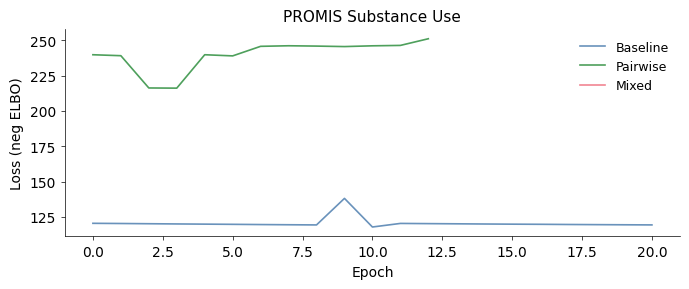

In [14]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='PROMIS Substance Use',
                          losses_pairwise=losses_pairwise)
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
calibrate_manually(model_pairwise, n_samples=32, seed=103)
calibrate_manually(model_imputed, n_samples=32, seed=102)

## 7. Ignorability Analysis

Compute per-item adaptive thresholds comparing pairwise imputation ELPD
against baseline IRT ELPD. Items whose missing values are **ignorable**
do not benefit from imputation over the baseline's own marginalization.

In [16]:
model_imputed.compute_adaptive_thresholds(
    data_factory, baseline_model=model_baseline, sample_size=32
)

import pandas as pd
ignorability_df = pd.DataFrame([
    {
        'Item': item,
        'w_pairwise': f"{mixed_imputation.get_item_weight(item):.4f}",
        'Threshold': f"{model_imputed._adaptive_thresholds[item]:.4f}",
        'Missing Ignorable': model_imputed._ignorable_items[item],
    }
    for item in item_keys
])
n_ignorable = sum(model_imputed._ignorable_items[k] for k in item_keys)
print(f"Ignorability: {n_ignorable}/{len(item_keys)} items have ignorable missing values\n")
print(ignorability_df.to_string(index=False))

model_imputed.save_to_disk('grm_imputed')

Ignorability: 0/144 items have ignorable missing values

      Item w_pairwise Threshold  Missing Ignorable
 sd1083R1d     0.5013    0.0010              False
 sd11004R1     0.6008    0.0010              False
 sd11007R1     0.5690    0.0010              False
 sd11015R1     0.5549    0.0010              False
sd11022R1d     0.5120    0.0010              False
sd11024R1d     0.4401    0.0010              False
sd11138R1d     0.4713    0.0010              False
sd11165R1d     0.3783    0.0010              False
 sd1116R1d     0.6273    0.0010              False
sd11193R1d     0.5770    0.0010              False
sd11200R1d     0.5082    0.0010              False
sd11208R1d     0.4157    0.0010              False
sd11229R1d     0.6286    0.0010              False
sd11252R1d     0.5200    0.0010              False
sd11299R1d     0.4123    0.0010              False
sd11316R1d     0.4357    0.0010              False
sd11323R1d     0.4774    0.0010              False
sd11350R1d     0.5154    

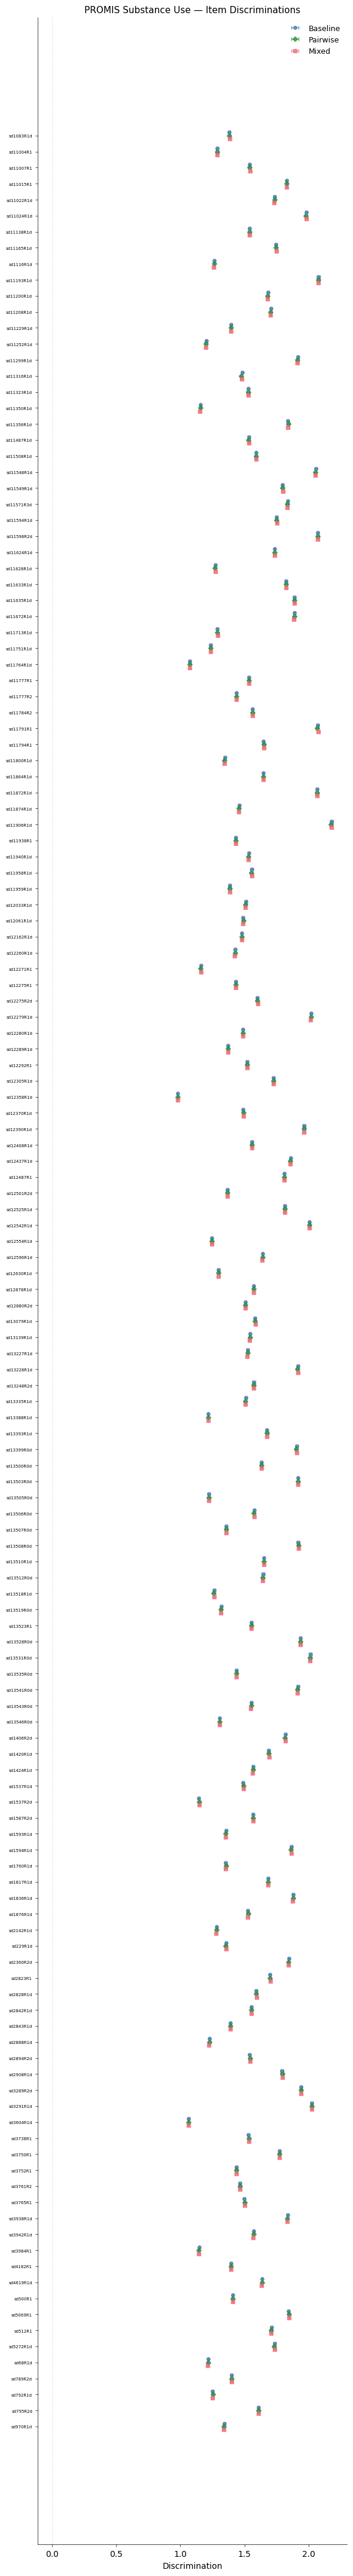

In [17]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed,
                                   title='PROMIS Substance Use — Item Discriminations',
                                   model_pairwise=model_pairwise)
fig.savefig('discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

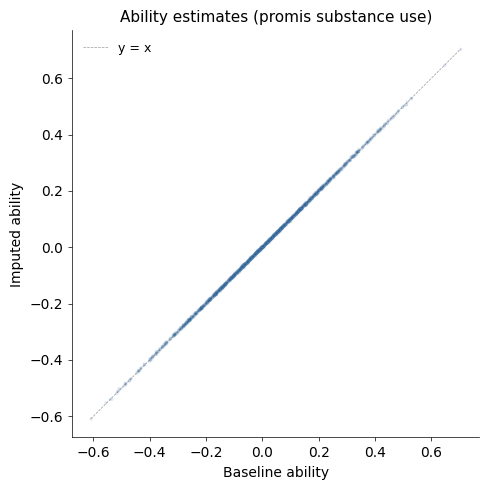

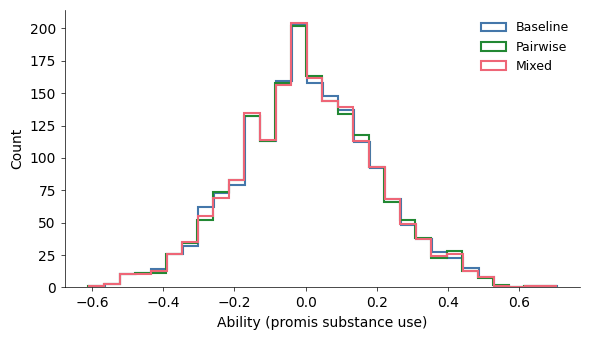

In [18]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_pw = np.array(model_pairwise.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='promis substance use')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='promis substance use',
                                  abilities_pairwise=ab_pw)
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

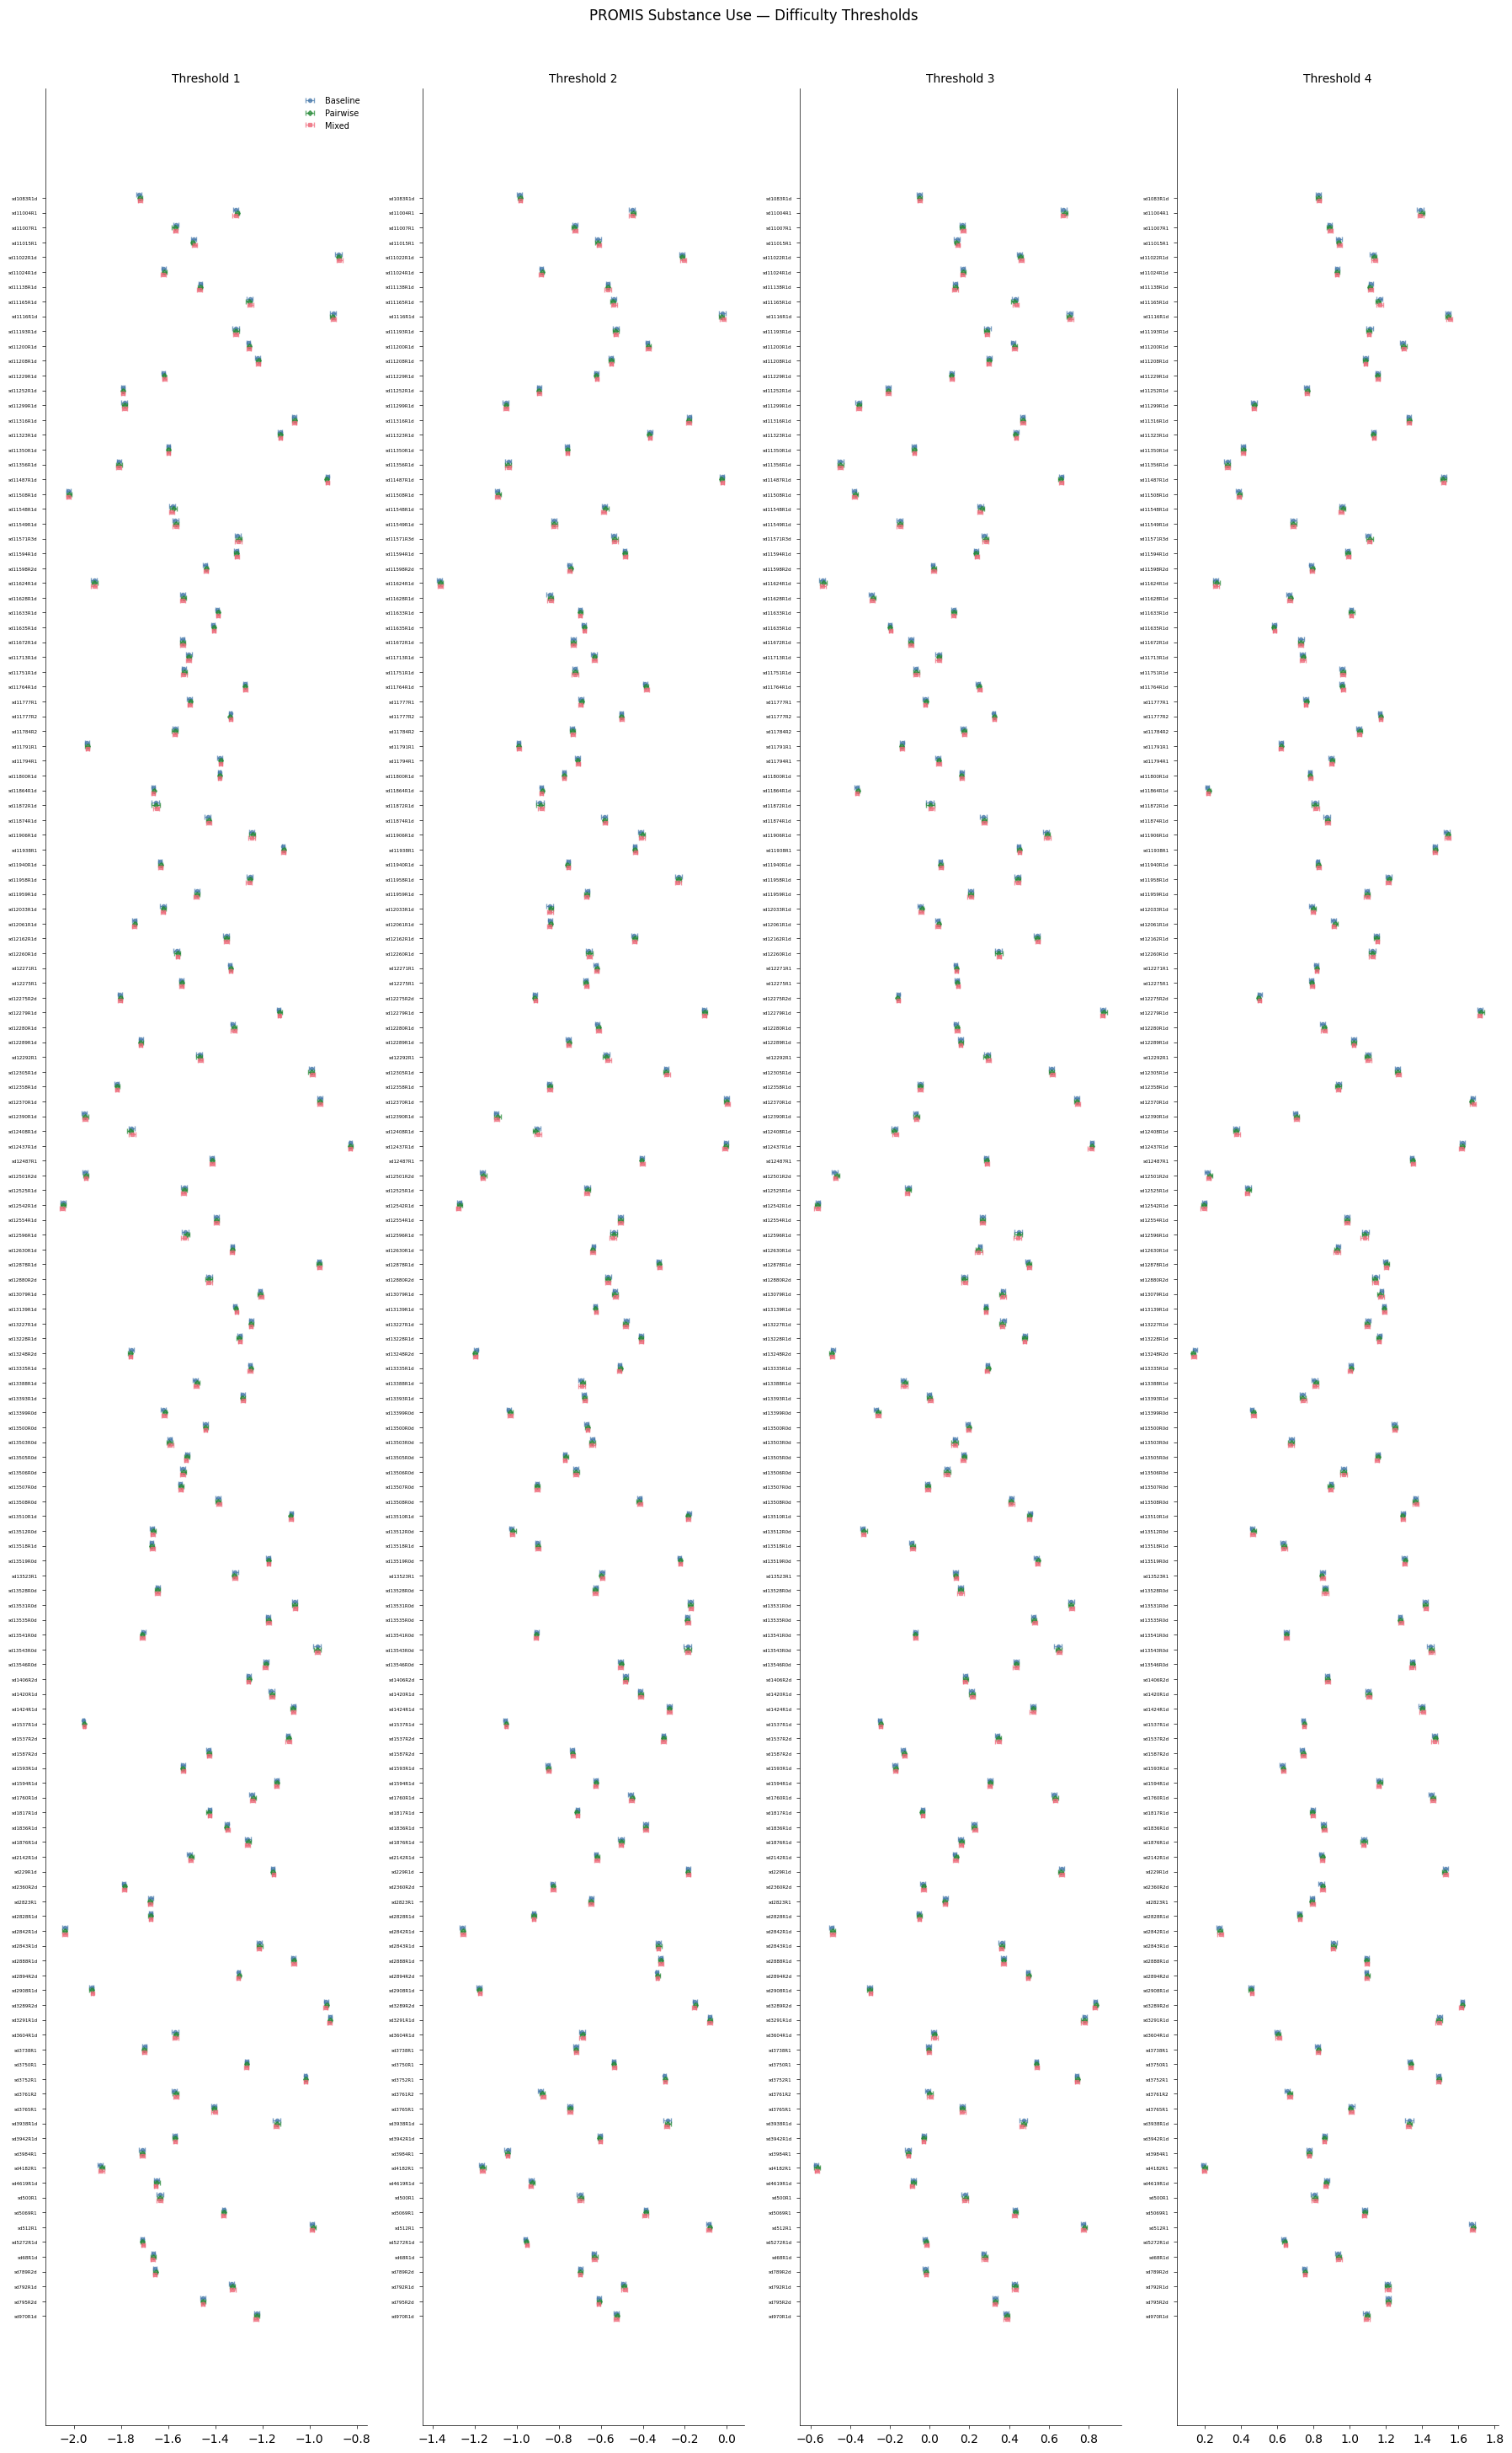

In [19]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed,
                       title='PROMIS Substance Use — Difficulty Thresholds',
                       model_pairwise=model_pairwise)
fig.savefig('thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

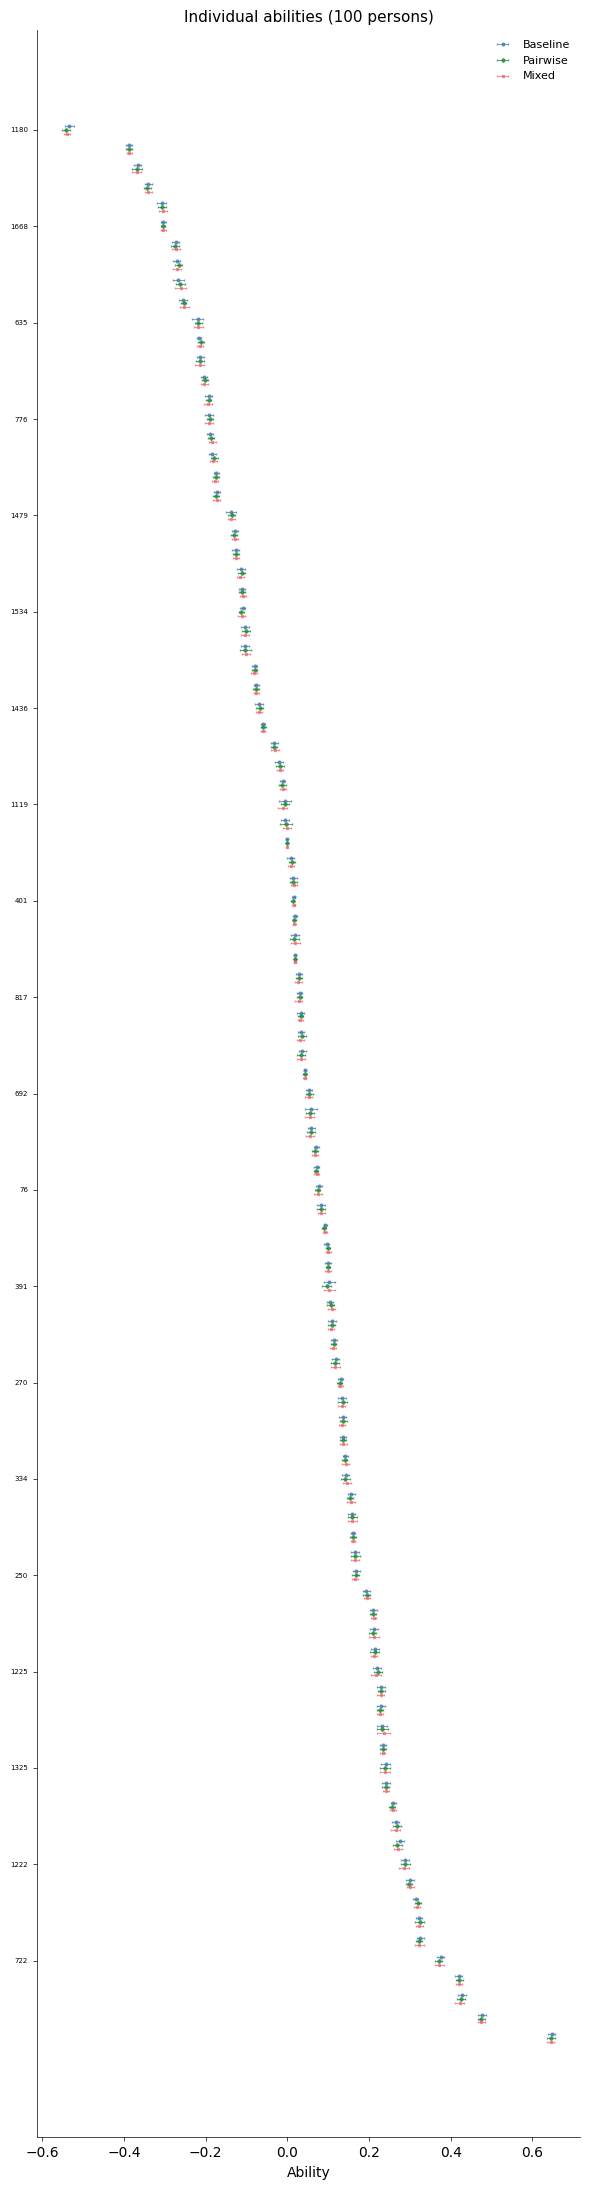

In [20]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed,
                                model_pairwise=model_pairwise)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

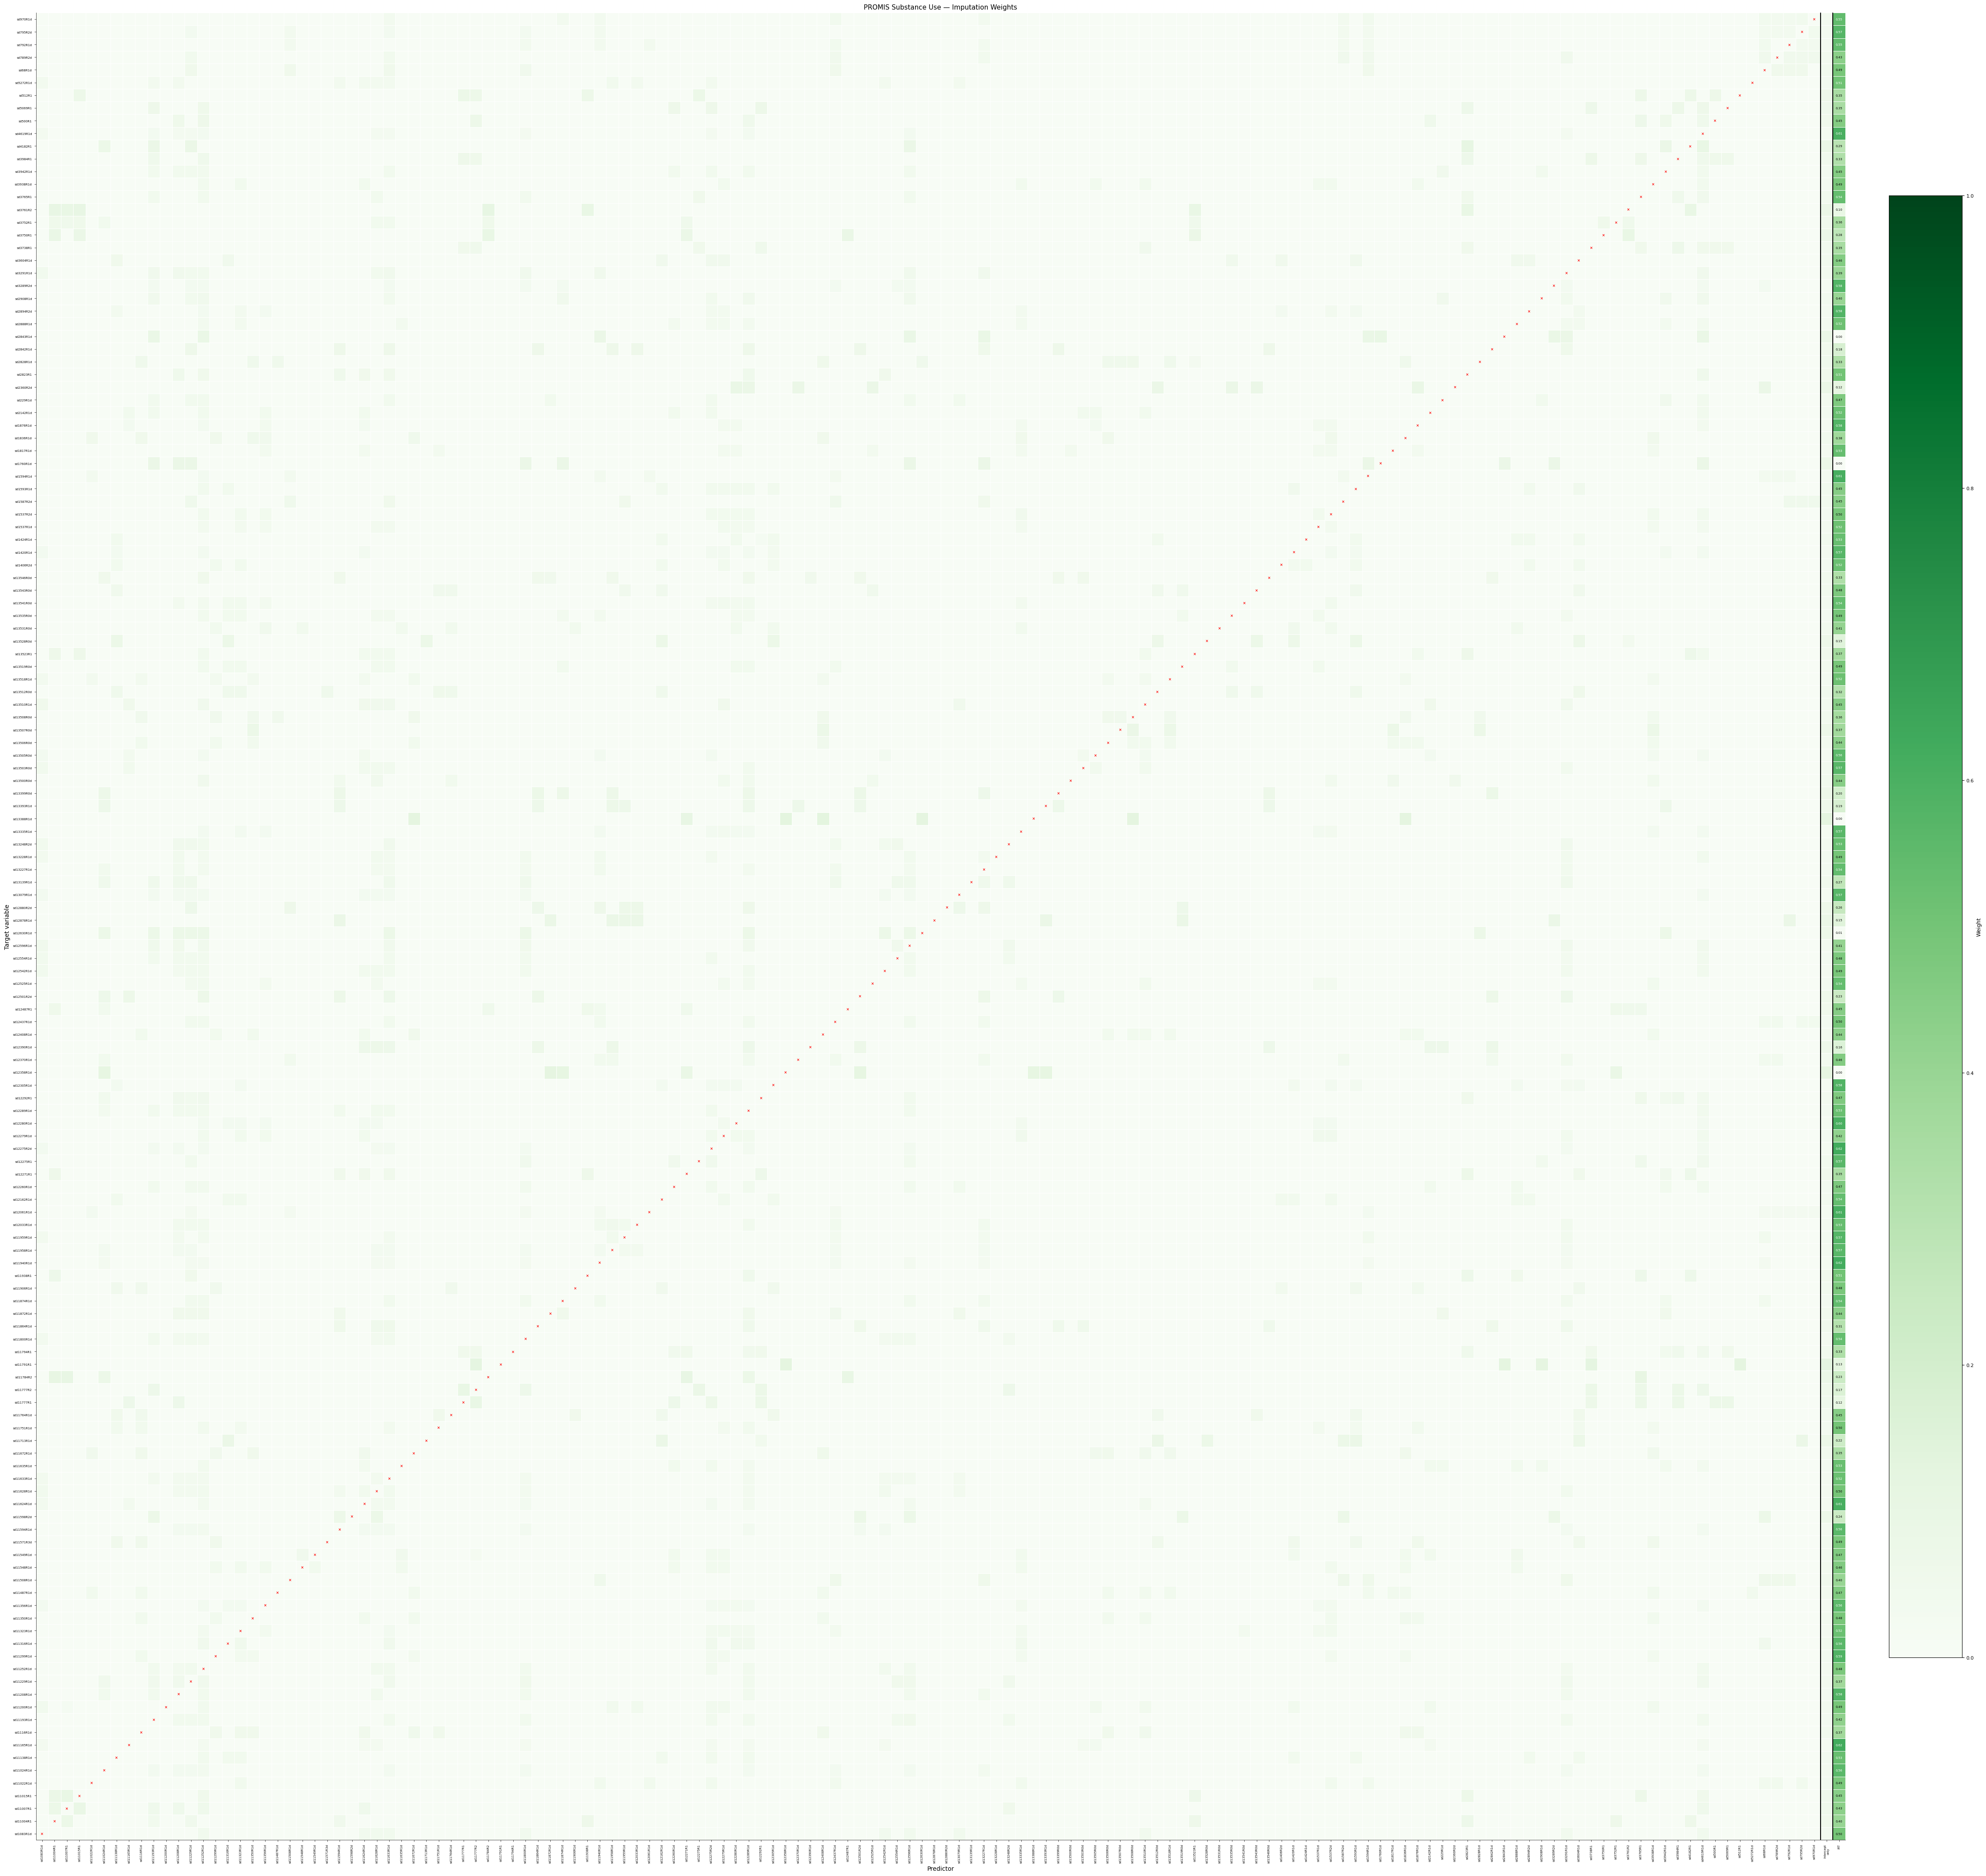

In [21]:
fig = plot_imputation_weights_pcolormesh(pairwise_model, mixed_imputation, item_keys,
                                          title='PROMIS Substance Use — Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 8. Model Comparison Table

Predictive performance comparison (RMSE and ELPD).

In [22]:
import pandas as pd
from scipy.stats import spearmanr

def compute_predictive_metrics(model, data_factory, item_keys, response_cardinality):
    K = response_cardinality
    all_ll, all_se, all_nr = [], [], []
    all_pred, all_obs = [], []
    for batch_data in data_factory():
        pred = model.predictive_distribution(batch_data, **model.surrogate_sample)
        probs = np.array(pred['rv'].probs_parameter())
        S, N_batch, I, _ = probs.shape
        for n in range(N_batch):
            ll, se, nr = 0.0, 0.0, 0
            for i, key in enumerate(item_keys):
                y = batch_data[key][n]
                if np.isnan(y) or y < 0 or y >= K: continue
                y_int = int(y)
                p_mean = probs[:, n, i, :].mean(0)
                ll += np.log(np.maximum(probs[:, n, i, y_int].mean(), 1e-30))
                expected = np.sum(p_mean * np.arange(K))
                se += (expected - y_int) ** 2
                all_pred.append(expected)
                all_obs.append(y_int)
                nr += 1
            if nr > 0: all_ll.append(ll); all_se.append(se); all_nr.append(nr)
    ll, se, nr = np.array(all_ll), np.array(all_se), np.array(all_nr)
    N, total = len(ll), nr.sum()
    rho, _ = spearmanr(all_obs, all_pred)
    return {
        'RMSE': (np.sqrt(se.sum()/total), np.std(np.sqrt(se/nr))/np.sqrt(N)),
        'ELPD/n': (ll.mean(), np.std(ll)/np.sqrt(N)),
        'ELPD/resp': (ll.sum()/total, np.std(ll/nr)/np.sqrt(N)),
        'Spearman': (rho, 0.0),
    }

m_b = compute_predictive_metrics(model_baseline, data_factory, item_keys, response_cardinality)
m_p = compute_predictive_metrics(model_pairwise, data_factory, item_keys, response_cardinality)
m_m = compute_predictive_metrics(model_imputed, data_factory, item_keys, response_cardinality)

rows = []
for metric in ['RMSE', 'ELPD/n', 'ELPD/resp', 'Spearman']:
    b_val, b_se = m_b[metric]
    p_val, p_se = m_p[metric]
    m_val, m_se = m_m[metric]
    if metric == 'Spearman':
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.4f}",
            'Pairwise': f"{p_val:.4f}",
            'Mixed': f"{m_val:.4f}",
        })
    else:
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.3f} ({b_se:.3f})",
            'Pairwise': f"{p_val:.3f} ({p_se:.3f})",
            'Mixed': f"{m_val:.3f} ({m_se:.3f})",
        })
print("PROMIS Substance Use — Predictive Performance Comparison\n")
print(pd.DataFrame(rows).to_string(index=False))

PROMIS Substance Use — Predictive Performance Comparison

   Metric         Baseline         Pairwise            Mixed
     RMSE    1.903 (0.012)    1.902 (0.012)    1.902 (0.012)
   ELPD/n -195.291 (2.870) -195.056 (2.866) -195.082 (2.866)
ELPD/resp   -2.060 (0.010)   -2.058 (0.010)   -2.058 (0.010)
 Spearman           0.0034           0.0040           0.0043


## Summary

This notebook fitted a single-scale Graded Response Model to the
PROMIS Substance Use calibration items with 5 response categories (0–4).

The dataset contains items from two banks: Severity of Substance Use
(37 items) and Positive Appeal of Substance Use (18 items).
N = 1,336 (875 general population + 461 addiction treatment).